# Classification Project — Model Training & Evaluation
### EV Battery Comparison with Machine Learning
---
> **How to use this notebook:** All code is hidden by default. Click **"Show / Hide Code"** at the top-right to reveal implementation details.
>
> This notebook covers the full supervised classification pipeline: preprocessing → training → evaluation → cross-validation → hyperparameter tuning. It directly implements concepts from **Lecture Sections 5, 6, and 8**.

---

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 0 — Presentation CSS + Toggle Button  (blue theme)
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display, Javascript

display(Javascript(r"""
(function() {

var css = `
  @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&family=Fira+Code:wght@400;500&display=swap');

  :root {
    --b50:#eff6ff; --b100:#dbeafe; --b200:#bfdbfe; --b400:#60a5fa;
    --b500:#3b82f6; --b600:#2563eb; --b700:#1d4ed8; --b800:#1e40af; --b900:#1e3a8a;
    --s50:#f8fafc;  --s100:#f1f5f9; --s200:#e2e8f0;
    --s600:#475569; --s700:#334155; --s800:#1e293b;
  }

  .jp-Notebook, #notebook-container { background: var(--s50) !important; }

  .jp-MarkdownOutput, .rendered_html, .text_cell_render {
    font-family: 'Inter', sans-serif !important; color: var(--s800); line-height: 1.75;
  }
  .jp-MarkdownOutput h1, .rendered_html h1, .text_cell_render h1 {
    font-size: 2.2rem; font-weight: 700; color: var(--b900);
    border-bottom: 4px solid var(--b500); padding-bottom: .4rem; margin-top: 1.5rem;
  }
  .jp-MarkdownOutput h2, .rendered_html h2, .text_cell_render h2 {
    font-size: 1.55rem; font-weight: 600; color: var(--b700);
    border-left: 5px solid var(--b500); padding-left: .75rem; margin-top: 2rem;
  }
  .jp-MarkdownOutput h3, .rendered_html h3, .text_cell_render h3 {
    font-size: 1.15rem; font-weight: 600; color: var(--b600); margin-top: 1.4rem;
  }
  .jp-MarkdownOutput blockquote, .rendered_html blockquote, .text_cell_render blockquote {
    background: var(--b50); border-left: 5px solid var(--b500);
    border-radius: 0 8px 8px 0; padding: 1rem 1.4rem;
    margin: 1rem 0; color: var(--s700); font-size: .97rem;
  }
  .jp-MarkdownOutput code, .rendered_html code, .text_cell_render code {
    font-family: 'Fira Code', monospace !important;
    background: var(--b100); color: var(--b900);
    padding: .1em .4em; border-radius: 4px; font-size: .88em;
  }
  .jp-MarkdownOutput table, .rendered_html table, .text_cell_render table {
    border-collapse: collapse; width: 100%; font-size: .93rem;
    border-radius: 8px; overflow: hidden; box-shadow: 0 1px 4px rgba(0,0,0,.08);
  }
  .jp-MarkdownOutput th, .rendered_html th, .text_cell_render th {
    background: var(--b700); color: white; padding: .6rem 1rem; text-align: left;
  }
  .jp-MarkdownOutput td, .rendered_html td, .text_cell_render td {
    padding: .5rem 1rem; border-bottom: 1px solid var(--s200);
  }
  .jp-MarkdownOutput tr:nth-child(even), .rendered_html tr:nth-child(even),
  .text_cell_render tr:nth-child(even) { background: var(--b50); }
  .jp-MarkdownOutput hr, .rendered_html hr, .text_cell_render hr {
    border: none; border-top: 2px solid var(--b200); margin: 2rem 0;
  }
  .jp-CodeCell .jp-Cell-inputWrapper,
  .code_cell .input { border-left: 3px solid var(--b400) !important; }
  .jp-OutputArea-output, .output_subarea { background: white; border-radius: 8px; }

  #nb-code-toggle {
    position: fixed !important; top: 18px !important; right: 24px !important;
    z-index: 999999 !important;
    background: linear-gradient(135deg, var(--b600), var(--b900));
    color: white; border: none; padding: 9px 20px; border-radius: 24px;
    font-family: 'Inter', sans-serif; font-size: .82rem; font-weight: 600;
    letter-spacing: .5px; cursor: pointer;
    box-shadow: 0 3px 12px rgba(37,99,235,.4);
    transition: transform .2s, box-shadow .2s;
  }
  #nb-code-toggle:hover { transform: translateY(-1px); box-shadow: 0 6px 18px rgba(37,99,235,.5); }

  .metric-grid {
    display: grid; grid-template-columns: repeat(auto-fit,minmax(150px,1fr));
    gap: 1rem; margin: 1.2rem 0;
  }
  .metric-card {
    background: white; border: 1px solid var(--b200); border-radius: 12px;
    padding: 1.1rem 1rem; text-align: center; box-shadow: 0 2px 8px rgba(0,0,0,.06);
  }
  .metric-card.best { border-color: var(--b500); background: var(--b50); }
  .metric-card .label {
    font-size: .75rem; font-weight: 600; text-transform: uppercase;
    letter-spacing: .8px; color: var(--b700); margin-bottom: .35rem;
  }
  .metric-card .value { font-size: 1.8rem; font-weight: 700; color: var(--s800); }
  .metric-card .sub  { font-size: .78rem; color: var(--s600); margin-top: .2rem; }
`;

var styleEl = document.getElementById('nb-presentation-style');
if (!styleEl) { styleEl = document.createElement('style'); styleEl.id = 'nb-presentation-style'; document.head.appendChild(styleEl); }
styleEl.textContent = css;

var existing = document.getElementById('nb-code-toggle');
if (existing) existing.remove();
var btn = document.createElement('button');
btn.id = 'nb-code-toggle';
btn.textContent = '⬇ Show Code';
var _hidden = true;

function getCodeInputs() {
  var els = Array.from(document.querySelectorAll('.jp-CodeCell .jp-Cell-inputWrapper'));
  if (els.length === 0) els = Array.from(document.querySelectorAll('.code_cell .input'));
  return els;
}
btn.addEventListener('click', function() {
  _hidden = !_hidden;
  getCodeInputs().forEach(function(el) { el.style.display = _hidden ? 'none' : ''; });
  btn.textContent = _hidden ? '⬇ Show Code' : '⬆ Hide Code';
});
document.body.appendChild(btn);

function autoHide(retries) {
  var cells = getCodeInputs();
  if (cells.length > 0) { cells.forEach(function(el) { el.style.display = 'none'; }); _hidden = true; btn.textContent = '⬇ Show Code'; }
  else if (retries > 0) { setTimeout(function() { autoHide(retries - 1); }, 400); }
}
setTimeout(function() { autoHide(10); }, 600);

})();
"""))


<IPython.core.display.Javascript object>

## 📦 Section 1 — Setup & Data Loading

> **What we do here:** Import all required libraries, load the dataset, and confirm everything looks right before modelling.

We use an **EV Customer Sentiment** dataset — extracted from approximately 870 real Reddit user reviews using Large Language Models (LLMs) to identify 6 core features. The target variable is **LLM_Satisfaction** (Positive, Neutral, Negative).
| Feature | Description |
|---------|-------------|
| `LLM_Battery` | The type of battery chemistry the user owns or discusses (e.g., NMC, LFP) |
| `LLM_Climate` | The typical weather conditions in the user's location (e.g., Cold, Hot, Mild) |
| `LLM_Commute` | The average distance or style of the user's daily commute (e.g., Short, Long) |
| `LLM_Home_Charging` | Whether the user has access to a dedicated home charger (Yes, No) |
| `LLM_Patience` | The psychological tolerance level of the user regarding EV constraints (High, Low) |
| `LLM_Brand` | The manufacturer/brand of the vehicle (e.g., Tesla, Hyundai, VW), grouped from specific model names to reduce sparsity. |
| **`LLM_Satisfaction`** | **[TARGET]** Overall sentiment regarding the EV experience (Positive, Neutral, Negative) |


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports & global plot settings
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

# sklearn — data
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing   import StandardScaler
from scipy.stats             import randint, uniform

# sklearn — models
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier

# sklearn — metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── Colour palette (blues) ────────────────────────────────────────────────────
BLUE   = "#2563eb"
BLUE_D = "#1e3a8a"
BLUE_L = "#bfdbfe"
SLATE  = "#334155"
ACCENT = "#60a5fa"
MODEL_COLORS = ["#1e3a8a","#1d4ed8","#2563eb","#3b82f6","#60a5fa","#93c5fd"]

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f8fafc",
    "axes.edgecolor"   : "#e2e8f0",
    "axes.grid"        : True,
    "grid.color"       : "#e2e8f0",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.7,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.titlecolor"  : "#1e3a8a",
    "axes.labelcolor"  : "#334155",
    "axes.labelsize"   : 11,
    "xtick.color"      : "#334155",
    "ytick.color"      : "#334155",
    "legend.framealpha": 0.9,
    "legend.edgecolor" : "#e2e8f0",
})

SEED = 42
np.random.seed(SEED)
print("\u2705  Libraries loaded successfully.")


✅  Libraries loaded successfully.


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load embedded dataset & Handle "Unknown" as Missing Values (np.nan)
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("data_will_use/reddit_training_data_roberta_final_new.csv")

TARGET = "LLM_Satisfaction"
FEATURES = [c for c in df.columns if c != TARGET]
#FEATURES = [f for f in FEATURES if f != 'LLM_Patience']
CLASS_NAMES = ['Negative', 'Neutral', 'Positive'] 

# METHODOLOGY FIX: "Unknown" is not a valid category. 
# It represents missing data. We replace it with NaN so the Pipeline can impute it properly.
df.replace("Unknown", np.nan, inplace=True)



print("--- DATASET SUMMARY ---")
print(f"Dataset shape  : {df.shape}")
print(f"Features       : {FEATURES}")
print(f"Target         : {TARGET}")
print(f"Class balance  : {df[TARGET].value_counts().to_dict()}\n")

print("--- MISSING VALUES (To be imputed in Pipeline) ---")
print(df[FEATURES].isna().sum())

df.head(5)



--- DATASET SUMMARY ---
Dataset shape  : (870, 7)
Features       : ['LLM_Model', 'LLM_Battery', 'LLM_Climate', 'LLM_Commute', 'LLM_Home_Charging', 'LLM_Patience']
Target         : LLM_Satisfaction
Class balance  : {'Positive': 442, 'Neutral': 270, 'Negative': 158}

--- MISSING VALUES (To be imputed in Pipeline) ---
LLM_Model              0
LLM_Battery            0
LLM_Climate          227
LLM_Commute          100
LLM_Home_Charging    140
LLM_Patience          88
dtype: int64


,LLM_Satisfaction,LLM_Model,LLM_Battery,LLM_Climate,LLM_Commute,LLM_Home_Charging,LLM_Patience
0,Negative,Tesla Model 3,NMC,Hot,Long,Yes,Low
1,Positive,Bolt EUV,NMC,Hot,Long,Yes,High
2,Neutral,Kia Niro EV,NMC,Cold,Long,Yes,Low
3,Neutral,Hyundai IONIQ 5,NMC,Cold,NaN,Yes,High
4,Positive,Toyota bz4x,NMC,Cold,Long,Yes,High


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# ---  Reduce LLM_Model to Brands to fix sparsity ---
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

def extract_brand(model_name):
    if pd.isnull(model_name) or model_name == 'Unknown' or model_name == 'nan':
        return np.nan
        
    model_name = str(model_name)
    
    # Custom mappings (e.g., as suggested by the professor for GM)
    brand_map = {
        'Chevy': 'GM', 
        'Chevrolet': 'GM', 
        'Bolt': 'GM',
        'Volkswagen': 'VW'
    }
    
    # Extract just the first word (e.g., "Tesla Model 3" -> "Tesla")
    brand = model_name.split()[0]
    
    # Return the mapped brand if it exists, otherwise return the first word
    return brand_map.get(brand, brand)


df['LLM_Brand'] = df['LLM_Model'].apply(extract_brand)


brand_counts = df['LLM_Brand'].value_counts()
df['LLM_Brand'] = df['LLM_Brand'].apply(
    lambda x: x if pd.isna(x) or brand_counts.get(x, 0) >= 10 else 'Other'
)

# Remove the overly specific 'LLM_Model' and add the grouped 'LLM_Brand'
if 'LLM_Model' in FEATURES:
    FEATURES.remove('LLM_Model')
    
if 'LLM_Brand' not in FEATURES:
    FEATURES.append('LLM_Brand')

print("[INFO] 'LLM_Model' removed from FEATURES. 'LLM_Brand' added.")
print(f"Updated Features List: {FEATURES}")

print("\nNew Class Distribution (LLM_Brand) after grouping rare brands as 'Other':")
print(df['LLM_Brand'].value_counts())


[INFO] 'LLM_Model' removed from FEATURES. 'LLM_Brand' added.
Updated Features List: ['LLM_Battery', 'LLM_Climate', 'LLM_Commute', 'LLM_Home_Charging', 'LLM_Patience', 'LLM_Brand']

New Class Distribution (LLM_Brand) after grouping rare brands as 'Other':
LLM_Brand
Tesla       452
VW           92
Hyundai      59
Ford         55
Nissan       49
Other        47
Kia          39
GM           29
Polestar     20
Rivian       17
BMW          11
Name: count, dtype: int64


---

## ✂️ Section 2 — Preprocessing & Train / Test Split

> **Lecture connection (Section 5 — Training):** The lecture introduces the **holdout method** and **K-fold cross-validation**, and warns that data must be **shuffled** before splitting to avoid ordering bias. We implement all of this here.

### Class Imbalance Check
Before splitting, we check the **class balance**. In classification, if one class is far more common than the other, a naive model that always predicts the majority class gets 95% accuracy — but is completely useless. We need to be aware of this when choosing metrics.

### Holdout Method (from Lecture)

| Set | Size | Purpose |
|-----|------|---------|
| **Training set** | 80 % | Model learns patterns from this data |
| **Test set** | 20 % | Final unbiased evaluation — touched only once |

### Feature Scaling
`StandardScaler` normalises each feature to zero mean and unit variance. This is essential for distance-based algorithms (KNN, SVM, Logistic Regression) which are sensitive to feature magnitudes.

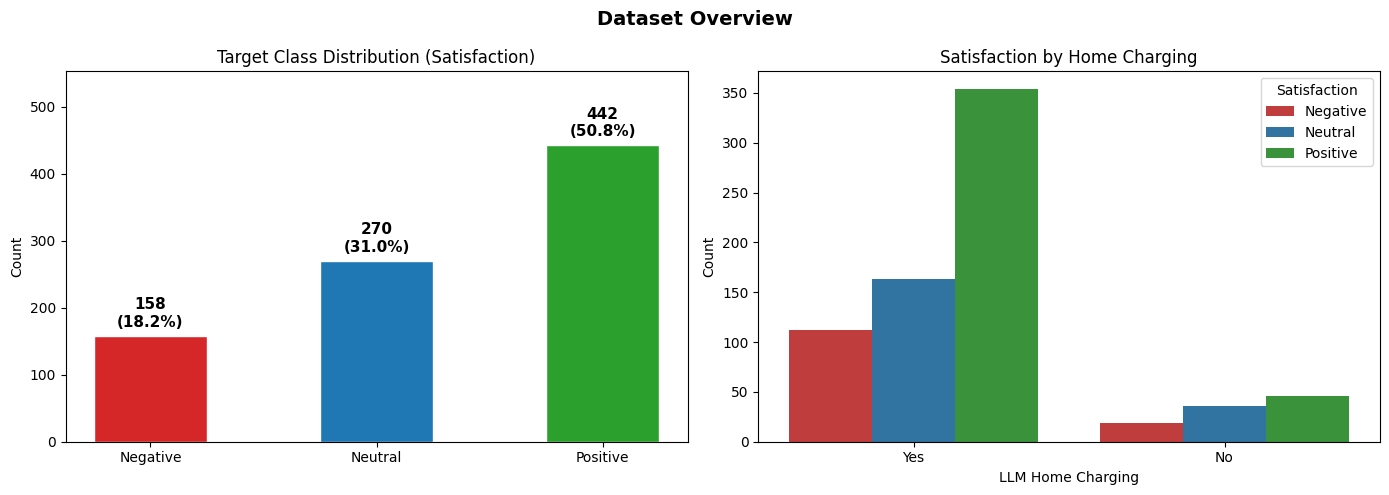

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Class balance visualisation
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns


COLORS = ['#d62728', '#1f77b4', '#2ca02c'] 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dataset Overview", fontsize=14, fontweight="bold")

# ── Left: class balance ───────────────────────────────────────────────────────
ax = axes[0]
counts = df[TARGET].value_counts().reindex(CLASS_NAMES)
bars   = ax.bar(CLASS_NAMES, counts.values, color=COLORS, edgecolor="white", width=0.5)

for bar, val in zip(bars, counts.values):
    
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (counts.max()*0.02),
            f"{val:,}\n({val/len(df):.1%})", ha="center", va="bottom",
            fontsize=11, fontweight="bold")
    
ax.set_ylabel("Count")
ax.set_title("Target Class Distribution (Satisfaction)")
ax.set_ylim(0, counts.max() * 1.25) 

# ── Right: feature distributions (Categorical) ───────────────────────────────
ax2 = axes[1]
sns.countplot(data=df, x="LLM_Home_Charging", hue=TARGET, palette=COLORS, hue_order=CLASS_NAMES, ax=ax2)
ax2.set_xlabel("LLM Home Charging")
ax2.set_ylabel("Count")
ax2.set_title("Satisfaction by Home Charging")
ax2.legend(title="Satisfaction")

plt.tight_layout()
plt.show()



In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Train/test split (NO MANUAL ENCODING - PIPELINE WILL HANDLE IT!)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

SEED = 42

X = df[FEATURES]
y = df[TARGET]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y  
)

print(f"Training samples : {len(X_train):,}  ({100*len(X_train)/len(df):.0f}%)")
print(f"Test samples     : {len(X_test):,}   ({100*len(X_test)/len(df):.0f}%)\n")

train_positive_rate = (y_train == 'Positive').mean()
test_positive_rate  = (y_test == 'Positive').mean()

print(f"Train 'Positive' rate : {train_positive_rate:.1%}")
print(f"Test 'Positive' rate  : {test_positive_rate:.1%}  (stratify=y kept the ratio consistent)")

print("\n[INFO] Data is intentionally kept RAW (not one-hot encoded or imputed yet).")
print("[INFO] Imputation and Encoding will be handled dynamically by the sklearn Pipeline to prevent data leakage!")




Training samples : 696  (80%)
Test samples     : 174   (20%)

Train 'Positive' rate : 50.9%
Test 'Positive' rate  : 50.6%  (stratify=y kept the ratio consistent)

[INFO] Data is intentionally kept RAW (not one-hot encoded or imputed yet).
[INFO] Imputation and Encoding will be handled dynamically by the sklearn Pipeline to prevent data leakage!


---

## 🤖 Section 3 — Model Training

> **What we do:** Train **six different classifiers** ranging from simple linear baselines to powerful ensemble methods. Training multiple models lets us compare their strengths and weaknesses on the same data.

### Models at a Glance

| # | Model | Type | Key Idea |
|---|-------|------|----------|
| 1 | **Logistic Regression** | Linear | Estimates probability using a sigmoid function |
| 2 | **K-Nearest Neighbours** | Distance-based | Classifies by majority vote of K nearest training points |
| 3 | **Decision Tree** | Non-linear | Splits data into rules using feature thresholds |
| 4 | **Random Forest** | Ensemble (bagging) | Averages many decision trees — reduces overfitting |
| 5 | **Gradient Boosting** | Ensemble (boosting) | Builds trees sequentially, each correcting previous errors |
| 6 | **Support Vector Machine** | Margin-based | Finds the hyperplane with the largest margin between classes |

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Define & train all classifiers (WITH SMOTEN PIPELINE)
# ─────────────────────────────────────────────────────────────────────────────
import time
import numpy as np

from imblearn.pipeline import Pipeline as ImbPipeline


from imblearn.over_sampling import SMOTEN

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

SEED = 42

models = {
    "Logistic Regression"  : LogisticRegression(max_iter=1000, random_state=SEED),
    "K-Nearest Neighbours" : KNeighborsClassifier(n_neighbors=7),
    "Decision Tree"        : DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "Random Forest"        : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                    random_state=SEED, n_jobs=-1),
    "Gradient Boosting"    : GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                        learning_rate=0.1, random_state=SEED),
    "SVM"                  : SVC(kernel="rbf", probability=True, random_state=SEED),
}

trained   = {}
fit_times = {}

print("\nTraining with Imputation + SMOTEN Pipeline...\n")

for name, model in models.items():
    t0 = time.time()
    
    
    pipe = ImbPipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("smoten", SMOTEN(random_state=SEED, k_neighbors=3)),
        ("enc", OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
        ("clf", model)
    ])
    
    pipe.fit(X_train, y_train)
    fit_times[name] = time.time() - t0
    trained[name]   = pipe  
    
    print(f"  \u2705  {name:<25} trained in {fit_times[name]:.2f}s")



Training with Imputation + SMOTEN Pipeline...

  ✅  Logistic Regression       trained in 0.04s
  ✅  K-Nearest Neighbours      trained in 0.02s
  ✅  Decision Tree             trained in 0.02s
  ✅  Random Forest             trained in 0.29s
  ✅  Gradient Boosting         trained in 0.48s
  ✅  SVM                       trained in 0.16s


---

## 📊 Section 4 — Evaluation Metrics Explained

> **Lecture connection (Section 6 — Evaluating the Accuracy of the Model):** The lecture covers the **confusion matrix**, **sensitivity**, **specificity**, **accuracy**, **precision**, **F1 score**, and **AUC-ROC** as the key evaluation tools for classification. All are implemented here and adapted for our multi-class sentiment analysis.

### The Confusion Matrix (Multi-Class Adaptation)

Since our project classifies EV reviews into three distinct sentiments rather than a binary outcome, our confusion matrix is a 3x3 grid. Every prediction falls into one of these cells:

| | Predicted: Positive | Predicted: Neutral | Predicted: Negative |
|--|---------------------|--------------------|---------------------|
| **Actual: Positive** | ✅ True Positive (Positive) | ❌ False Neutral | ❌ False Negative |
| **Actual: Neutral** | ❌ False Positive | ✅ True Positive (Neutral) | ❌ False Negative |
| **Actual: Negative** | ❌ False Positive | ❌ False Neutral | ✅ True Positive (Negative) |

*(Note: In multi-class classification, True Positives, False Positives, and False Negatives are calculated individually for **each class**, and then averaged using methods like `macro` or `weighted` averages.)*

### Metrics Derived from the Confusion Matrix

| Metric | Formula (Per Class basis) | What It Asks in Our Context | Lecture? |
|--------|---------------------------|-----------------------------|---------|
| **Accuracy** | $(Total Correct) / (Total Predictions)$ | What % of all Reddit EV reviews were correctly classified? | ✅ |
| **Sensitivity (Recall)** | $TP/(TP+FN)$ | What % of actual *Negative* (or Positive) reviews did the model successfully catch? | ✅ |
| **Precision** | $TP/(TP+FP)$ | Out of all reviews the model *labeled* as Negative, how many were actually Negative? | ✅ |
| **F1 Score** | $2 \cdot \frac{Precision \cdot Recall}{Precision+Recall}$ | Harmonic mean of precision & recall (Crucial for our highly imbalanced *Neutral* class!) | ✅ |
| **AUC-ROC** | Area under the ROC curve (OVR - One vs Rest) | How well does the model separate one sentiment from the others across different thresholds? | ✅ |

> 💡 **Which metric matters most for our EV Sentiment Project?** 
> It depends on the manufacturer's goal. For an EV manufacturer analyzing Reddit feedback, **missing a Negative review (False Negative) is highly costly**, as negative reviews contain critical pain points (e.g., cold weather degradation, charging anxiety). Therefore, **Recall/Sensitivity for the Negative class** is prioritized. 
> Furthermore, because our dataset suffers from severe class imbalance (very few *Neutral* samples compared to *Positive/Negative*), the **Weighted F1-Score** is a much more reliable metric than raw Accuracy, as it severely punishes the model for ignoring the minority class.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Compute all metrics for every model (NO _enc used!)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
from IPython.display import display

results = []

for name, model in trained.items():
  
    # IMPORTANT: Use raw X_train and X_test! The Pipeline handles the encoding.
    y_pred_tr = model.predict(X_train)
    y_pred_te = model.predict(X_test)
    
    y_prob_te = model.predict_proba(X_test) 

    results.append({
        "Model"         : name,
        "Train Accuracy": accuracy_score(y_train, y_pred_tr),
        "Test Accuracy" : accuracy_score(y_test,  y_pred_te),
        
        "Precision"     : precision_score(y_test, y_pred_te, zero_division=0, average="weighted"),
        "Recall"        : recall_score(y_test, y_pred_te, zero_division=0, average="weighted"),
        "F1 Score"      : f1_score(y_test, y_pred_te, zero_division=0, average="weighted"),
        
        "AUC-ROC"       : roc_auc_score(y_test, y_prob_te, multi_class="ovr", average="weighted"),
        "Fit Time (s)"  : fit_times[name],
    })

results_df = pd.DataFrame(results).set_index("Model")

styled = (results_df
    .style
    .format({
        "Train Accuracy": "{:.4f}", "Test Accuracy": "{:.4f}",
        "Precision"     : "{:.4f}", "Recall"       : "{:.4f}",
        "F1 Score"      : "{:.4f}", "AUC-ROC"      : "{:.4f}",
        "Fit Time (s)"  : "{:.2f}",
    })
    .background_gradient(subset=["AUC-ROC"],     cmap="Blues", vmin=0.5, vmax=1.0)
    .background_gradient(subset=["F1 Score"],    cmap="Blues", vmin=0.0, vmax=1.0)
    .highlight_max(subset=["Test Accuracy","F1 Score","AUC-ROC"], color="#bfdbfe")
    .set_caption("Model Performance Summary — All metrics on held-out test set")
)

display(styled)





,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,AUC-ROC,Fit Time (s)
Model,,,,,,,
Logistic Regression,0.4914,0.4483,0.5294,0.4483,0.4562,0.6969,0.04
K-Nearest Neighbours,0.6394,0.5460,0.5720,0.5460,0.5530,0.6848,0.02
Decision Tree,0.5718,0.4943,0.5675,0.4943,0.5104,0.6758,0.02
Random Forest,0.6279,0.4828,0.5484,0.4828,0.4948,0.7276,0.29
Gradient Boosting,0.6293,0.4713,0.5283,0.4713,0.4812,0.6850,0.48
SVM,0.6006,0.4655,0.5227,0.4655,0.4788,0.6927,0.16


---

## 📈 Section 5 — Visual Model Comparison

> **Charts make the trade-offs immediately visible.** The bar charts below compare all models on the metrics that matter most for classification.

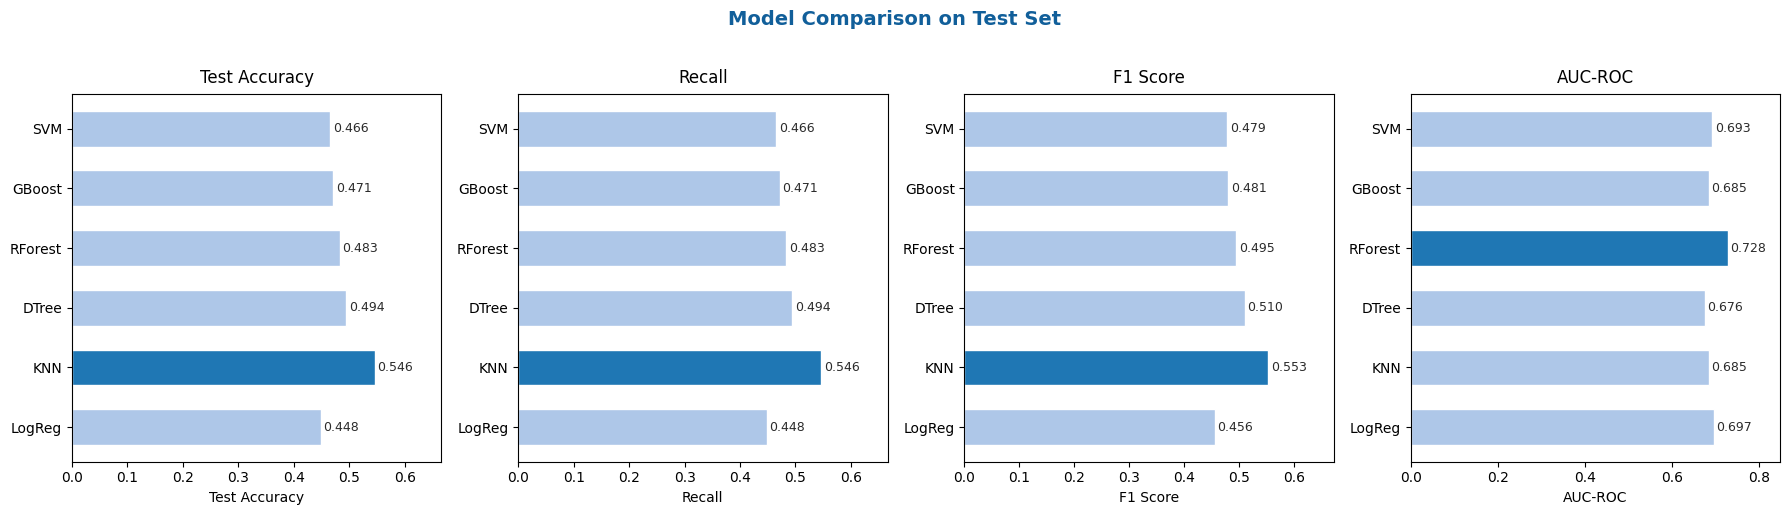

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Bar chart comparison
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt


BLUE_D = "#115f9a" 
BLUE   = "#1f77b4"
BLUE_L = "#aec7e8"
SLATE  = "#2b2b2b"

model_names  = results_df.index.tolist()

short_names  = ["LogReg","KNN","DTree","RForest","GBoost","SVM"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Model Comparison on Test Set", fontsize=14, fontweight="bold", color=BLUE_D, y=1.02)


for ax, col in zip(axes, ["Test Accuracy","Recall","F1 Score","AUC-ROC"]):
    vals = results_df[col].values
    best = np.argmax(vals) 
    
    
    cols = [BLUE if i==best else BLUE_L for i in range(len(vals))]
    
    ax.barh(short_names, vals, color=cols, edgecolor="white", height=0.6)
    ax.set_xlabel(col)
    ax.set_title(col, pad=8)
    ax.set_xlim(0, min(1.0, vals.max()+0.12))
    
    for i, val in enumerate(vals):
        ax.text(val+0.005, i, f"{val:.3f}", va="center", fontsize=9, color=SLATE)

plt.tight_layout()
plt.show()



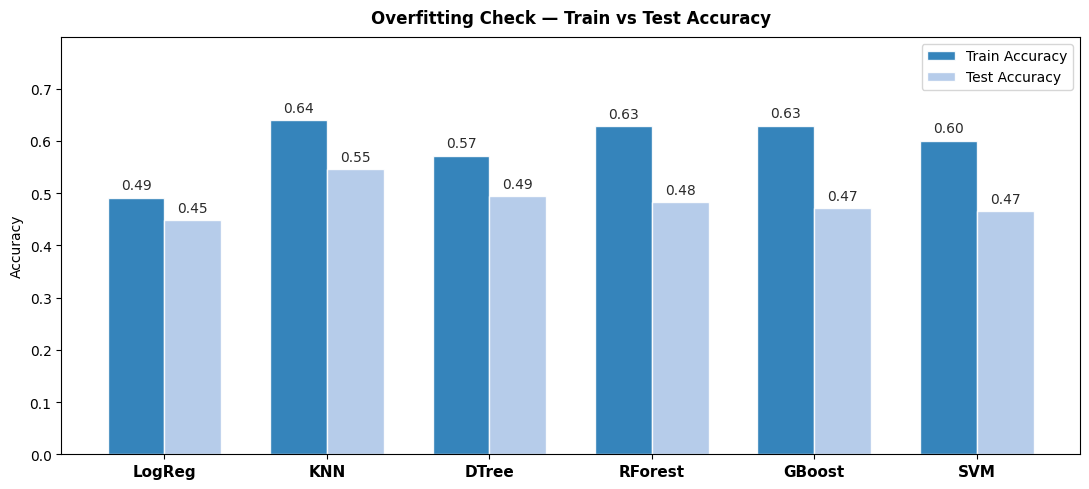

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Overfitting check: Train Accuracy vs Test Accuracy
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt


BLUE   = "#1f77b4"
BLUE_L = "#aec7e8"
SLATE  = "#2b2b2b"

fig, ax = plt.subplots(figsize=(11, 5))


x_pos = np.arange(len(short_names))
width = 0.35


bars_tr = ax.bar(x_pos - width/2, results_df["Train Accuracy"], width,
                  label="Train Accuracy", color=BLUE,   edgecolor="white", alpha=0.9)

bars_te = ax.bar(x_pos + width/2, results_df["Test Accuracy"],  width,
                  label="Test Accuracy",  color=BLUE_L,  edgecolor="white", alpha=0.9)


for bar in list(bars_tr) + list(bars_te):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f"{h:.2f}", ha="center", va="bottom", fontsize=10, color=SLATE)


ax.set_xticks(x_pos)
ax.set_xticklabels(short_names, fontsize=11, fontweight="bold")
ax.set_ylabel("Accuracy")


ax.set_ylim(0, max(results_df["Train Accuracy"].max(), results_df["Test Accuracy"].max()) * 1.25)
ax.set_title("Overfitting Check — Train vs Test Accuracy", pad=10, fontweight="bold")


ax.legend(loc="upper right")


ax.axhline(1.0, color="#dc2626", linewidth=1.5, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()



> 💡 **Interpreting the overfitting chart:** A large gap between train and test accuracy means the model memorised the training data rather than learning general patterns. Decision Trees without pruning are particularly prone to this. Ensemble methods like Random Forest and Gradient Boosting generalise much better.

---

## 🔲 Section 6 — Confusion Matrices

> **Lecture connection (Section 6):** The lecture introduces the confusion matrix as the fundamental tool for evaluating classifiers. It shows all four outcomes — TP, FP, FN, TN — in a single table, letting us calculate sensitivity, specificity, precision, and F1 directly.

A confusion matrix for all six models is shown below so we can compare not just overall accuracy, but the *pattern* of errors each model makes.

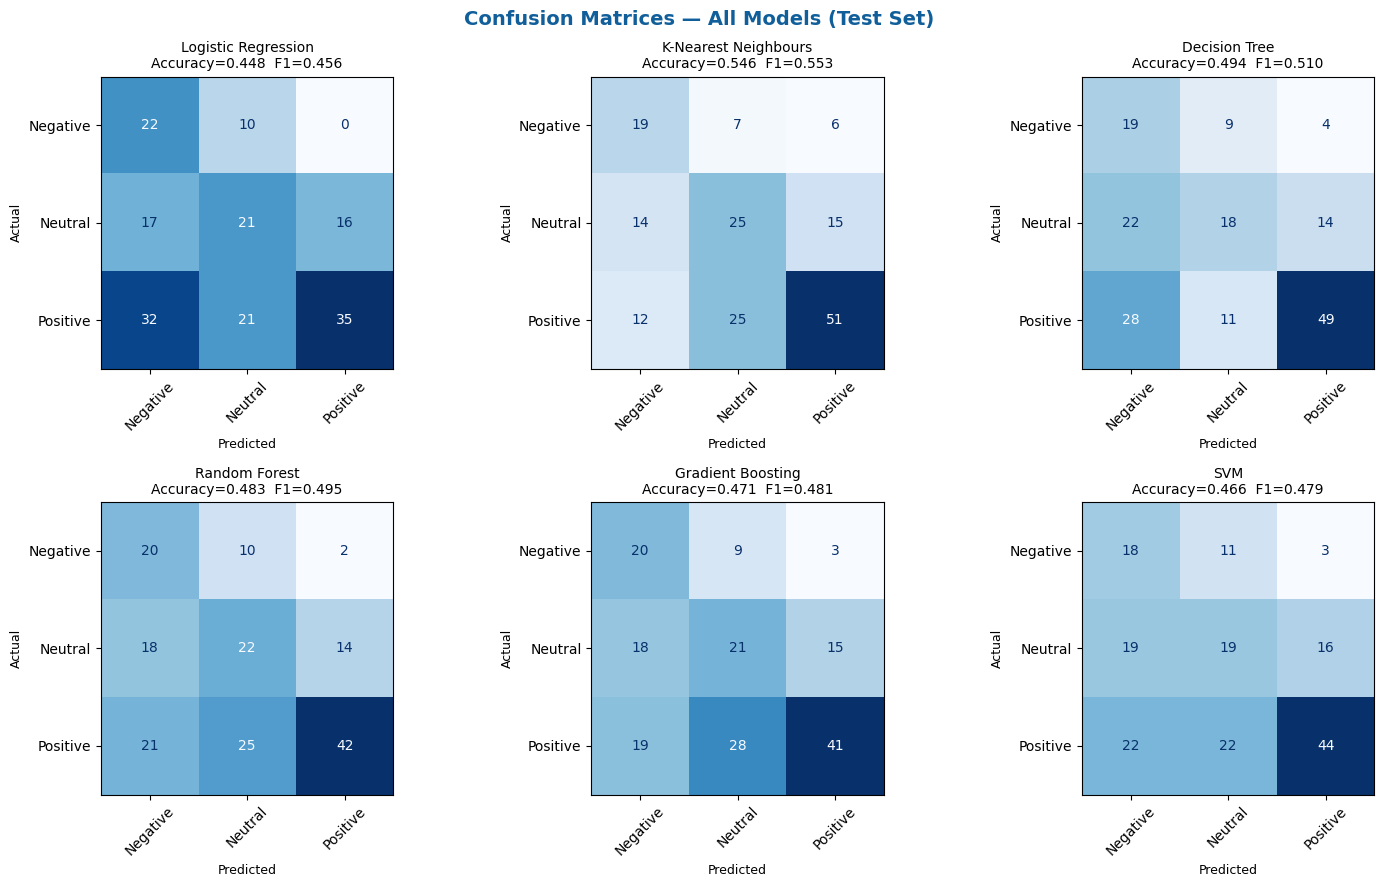

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Confusion matrix grid for all models (NO _enc used!)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import matplotlib.pyplot as plt


ORDERED_CLASSES = ['Negative', 'Neutral', 'Positive']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
BLUE_D = "#115f9a" 
fig.suptitle("Confusion Matrices — All Models (Test Set)", fontsize=14, fontweight="bold", color=BLUE_D)

cmap = plt.cm.Blues

for ax, (name, model) in zip(axes.flat, trained.items()):
    
    
    y_pred = model.predict(X_test)
    
    
    cm = confusion_matrix(y_test, y_pred, labels=ORDERED_CLASSES)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, zero_division=0, average="weighted")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ORDERED_CLASSES)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    
    ax.set_title(f"{name}\nAccuracy={acc:.3f}  F1={f1:.3f}", fontsize=10, pad=6)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Actual", fontsize=9)

    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()




---

## 📉 Section 7 — ROC Curves & AUC

> **Lecture connection (Section 6):** The lecture covers the **ROC (Receiver Operating Characteristic) curve** and **AUC-ROC** as the standard way to compare classifiers across all possible thresholds. The lecture states: *"AUC-ROC is used to easily compare one model to another."*

### How ROC Works (from Lecture)
- By default a classifier uses a 0.5 probability threshold to decide Positive vs Neutral vs Negative
- The **ROC curve** plots **True Positive Rate (Sensitivity)** vs **False Positive Rate (1 − Specificity)** for every possible threshold from 0 to 1
- The **AUC** (Area Under the Curve) summarises this into one number: 1.0 = perfect, 0.5 = random guessing
- The **diagonal line** represents a random classifier — any model above it is adding value

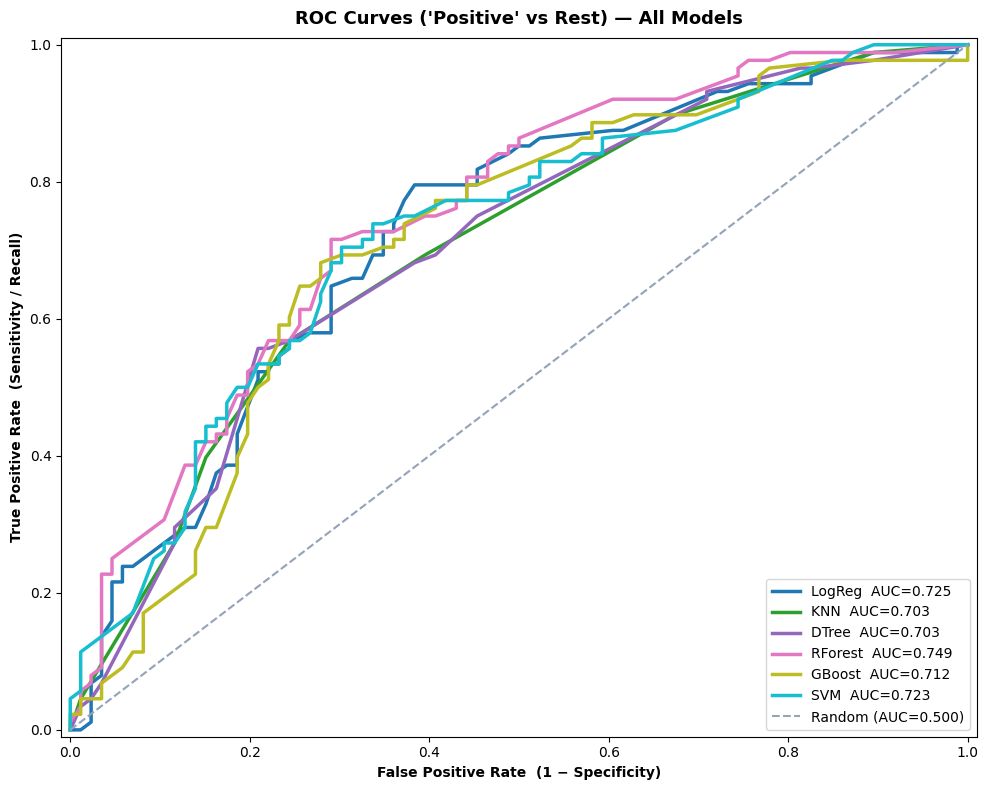

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — ROC curves for all models (OvR)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))


colors = plt.cm.tab10(np.linspace(0, 1, len(trained)))


y_test_binary = (y_test == 'Positive').astype(int)

for (name, model), color in zip(trained.items(), colors):
    
    pos_idx = list(model.classes_).index('Positive')
    
    
    y_prob = model.predict_proba(X_test)[:, pos_idx]
    
    
    fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
    auc = roc_auc_score(y_test_binary, y_prob)
    
    
    sname = dict(zip(
        ["Logistic Regression","K-Nearest Neighbours","Decision Tree",
         "Random Forest","Gradient Boosting","SVM"],
        ["LogReg","KNN","DTree","RForest","GBoost","SVM"]
    )).get(name, name)
    
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f"{sname}  AUC={auc:.3f}")


ax.plot([0,1],[0,1], "--", color="#94a3b8", linewidth=1.5, label="Random (AUC=0.500)")
ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color="#94a3b8")

ax.set_xlabel("False Positive Rate  (1 − Specificity)", fontweight="bold")
ax.set_ylabel("True Positive Rate  (Sensitivity / Recall)", fontweight="bold")
ax.set_title("ROC Curves ('Positive' vs Rest) — All Models", fontsize=13, pad=10, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)

plt.tight_layout()
plt.show()


> 💡 **Threshold insight (from lecture):** The ROC curve lets you pick a threshold based on your business need. If missing a churner is very costly, you slide the threshold lower — this catches more churners (higher TPR) but also raises false alarms (higher FPR). The right threshold depends on the *relative cost of each error type*.

---

## 🏆 Section 8 — Deep Dive into the Best Model

> **We now focus on the top-performing model** (by AUC-ROC) for a thorough diagnostic — detailed confusion matrix, per-class metrics, and feature importance.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Identify best model by AUC-ROC + show metric cards
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display, HTML

best_name  = results_df["AUC-ROC"].idxmax()

b_acc  = results_df.loc[best_name, "Test Accuracy"]
b_prec = results_df.loc[best_name, "Precision"]
b_rec  = results_df.loc[best_name, "Recall"]
b_f1   = results_df.loc[best_name, "F1 Score"]
b_auc  = results_df.loc[best_name, "AUC-ROC"]

banner_html = """
<div style="background:linear-gradient(135deg,#1e3a8a,#2563eb);color:white;
     border-radius:12px;padding:1.2rem 1.6rem;margin:1rem 0;font-family:sans-serif;">
  <div style="font-size:.8rem;opacity:.85;text-transform:uppercase;letter-spacing:1px;">BEST MODEL (Based on AUC-ROC Score)</div>
  <div style="font-size:1.6rem;font-weight:700;margin:.3rem 0;">&#127942; {name}</div>
  <div style="font-size:.9rem;opacity:.9;">Highest class separation capability among all trained models</div>
</div>

<div style="display:flex; gap:10px; flex-wrap:wrap; font-family:sans-serif;">
  <div style="background:#eff6ff; padding:15px; border-radius:8px; flex:1; min-width:120px; border-left:4px solid #2563eb;">
    <div style="font-size:0.8rem; color:#475569; font-weight:bold;">AUC-ROC</div>
    <div style="font-size:1.4rem; color:#1e3a8a; font-weight:800;">{auc}</div>
    <div style="font-size:0.65rem; color:#64748b; margin-top:4px;">Class Separation (Ranking)</div>
  </div>
  
  <div style="background:#f8fafc; padding:15px; border-radius:8px; flex:1; min-width:120px; border:1px solid #e2e8f0;">
    <div style="font-size:0.8rem; color:#475569; font-weight:bold;">Accuracy</div>
    <div style="font-size:1.4rem; color:#334155; font-weight:800;">{acc}</div>
    <div style="font-size:0.65rem; color:#64748b; margin-top:4px;">Overall Accuracy</div>
  </div>
  
  <div style="background:#f8fafc; padding:15px; border-radius:8px; flex:1; min-width:120px; border:1px solid #e2e8f0;">
    <div style="font-size:0.8rem; color:#475569; font-weight:bold;">Recall (Weighted)</div>
    <div style="font-size:1.4rem; color:#334155; font-weight:800;">{rec}</div>
    <div style="font-size:0.65rem; color:#64748b; margin-top:4px;">Balanced Sensitivity</div>
  </div>
  
  <div style="background:#f8fafc; padding:15px; border-radius:8px; flex:1; min-width:120px; border:1px solid #e2e8f0;">
    <div style="font-size:0.8rem; color:#475569; font-weight:bold;">Precision (Weighted)</div>
    <div style="font-size:1.4rem; color:#334155; font-weight:800;">{prec}</div>
    <div style="font-size:0.65rem; color:#64748b; margin-top:4px;">Balanced Precision</div>
  </div>
  
  <div style="background:#f8fafc; padding:15px; border-radius:8px; flex:1; min-width:120px; border:1px solid #e2e8f0;">
    <div style="font-size:0.8rem; color:#475569; font-weight:bold;">F1 Score</div>
    <div style="font-size:1.4rem; color:#334155; font-weight:800;">{f1}</div>
    <div style="font-size:0.65rem; color:#64748b; margin-top:4px;">Precision–Recall Balance</div>
  </div>
</div>
""".format(
    name=best_name,
    auc="{:.4f}".format(b_auc),
    acc="{:.4f}".format(b_acc),
    rec="{:.4f}".format(b_rec),
    prec="{:.4f}".format(b_prec),
    f1="{:.4f}".format(b_f1),
)

display(HTML(banner_html))



In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11.5 — 
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display, HTML


best_name = (results_df["F1 Score"] + results_df["Test Accuracy"]).idxmax()

b_acc  = results_df.loc[best_name, "Test Accuracy"]
b_prec = results_df.loc[best_name, "Precision"]
b_rec  = results_df.loc[best_name, "Recall"]
b_f1   = results_df.loc[best_name, "F1 Score"]
b_auc  = results_df.loc[best_name, "AUC-ROC"]

banner_html = """
<div style="background:linear-gradient(135deg,#047857,#059669);color:white;
     border-radius:12px;padding:1.2rem 1.6rem;margin:1rem 0;font-family:sans-serif;">
  <div style="font-size:.8rem;opacity:.85;text-transform:uppercase;letter-spacing:1px;">RECOMMENDED MODEL</div>
  <div style="font-size:1.6rem;font-weight:700;margin:.3rem 0;">&#127807; {name}</div>
  <div style="font-size:.9rem;opacity:.9;">Selected for balanced Accuracy, F1-Score, and reliable 'Neutral' class detection(Confusion Matrix)</div>
</div>

<div style="display:flex; gap:10px; flex-wrap:wrap; font-family:sans-serif;">
  <div style="background:#f8fafc; padding:15px; border-radius:8px; flex:1; min-width:120px; border:1px solid #e2e8f0;">
    <div style="font-size:0.8rem; color:#475569; font-weight:bold;">AUC-ROC</div>
    <div style="font-size:1.4rem; color:#334155; font-weight:800;">{auc}</div>
    <div style="font-size:0.65rem; color:#64748b; margin-top:4px;">Class Separation</div>
  </div>
  
  <div style="background:#ecfdf5; padding:15px; border-radius:8px; flex:1; min-width:120px; border-left:4px solid #10b981;">
    <div style="font-size:0.8rem; color:#475569; font-weight:bold;">Accuracy</div>
    <div style="font-size:1.4rem; color:#047857; font-weight:800;">{acc}</div>
    <div style="font-size:0.65rem; color:#64748b; margin-top:4px;">Overall Correct</div>
  </div>
  
  <div style="background:#f8fafc; padding:15px; border-radius:8px; flex:1; min-width:120px; border:1px solid #e2e8f0;">
    <div style="font-size:0.8rem; color:#475569; font-weight:bold;">Recall (Weighted)</div>
    <div style="font-size:1.4rem; color:#334155; font-weight:800;">{rec}</div>
    <div style="font-size:0.65rem; color:#64748b; margin-top:4px;">Balanced Sensitivity</div>
  </div>
  
  <div style="background:#f8fafc; padding:15px; border-radius:8px; flex:1; min-width:120px; border:1px solid #e2e8f0;">
    <div style="font-size:0.8rem; color:#475569; font-weight:bold;">Precision (Weighted)</div>
    <div style="font-size:1.4rem; color:#334155; font-weight:800;">{prec}</div>
    <div style="font-size:0.65rem; color:#64748b; margin-top:4px;">Balanced Precision</div>
  </div>
  
  <div style="background:#ecfdf5; padding:15px; border-radius:8px; flex:1; min-width:120px; border-left:4px solid #10b981;">
    <div style="font-size:0.8rem; color:#475569; font-weight:bold;">F1 Score</div>
    <div style="font-size:1.4rem; color:#047857; font-weight:800;">{f1}</div>
    <div style="font-size:0.65rem; color:#64748b; margin-top:4px;">Precision-Recall Balance</div>
  </div>
</div>
""".format(
    name=best_name,
    auc="{:.4f}".format(b_auc),
    acc="{:.4f}".format(b_acc),
    rec="{:.4f}".format(b_rec),
    prec="{:.4f}".format(b_prec),
    f1="{:.4f}".format(b_f1),
)

display(HTML(banner_html))



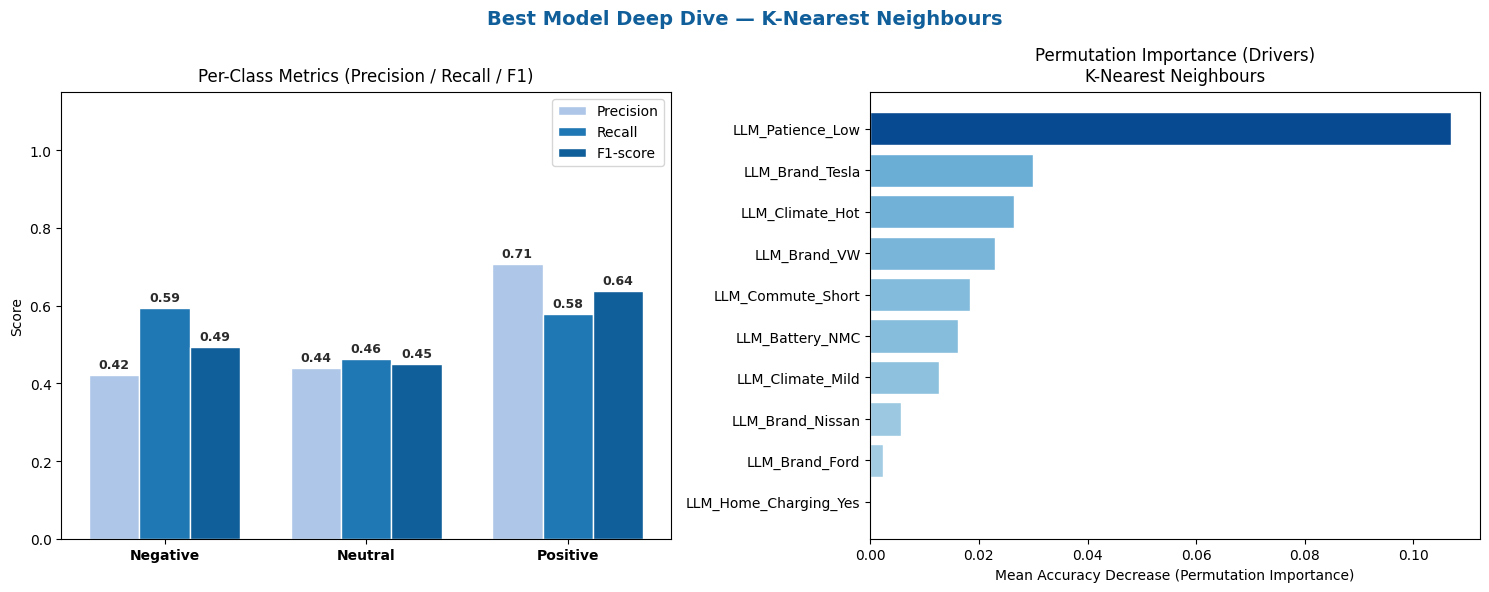

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Classification report + feature importance for best model
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE_D = "#115f9a" 
BLUE   = "#1f77b4"
BLUE_L = "#aec7e8"
SLATE  = "#2b2b2b"

best_name  = (results_df["F1 Score"] + results_df["Test Accuracy"]).idxmax()
best_pipe  = trained[best_name] 
best_clf   = best_pipe.named_steps["clf"]

y_best = best_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Best Model Deep Dive — {best_name}", fontsize=14, fontweight="bold", color=BLUE_D)
ax = axes[0]

report = classification_report(y_test, y_best, labels=CLASS_NAMES, target_names=CLASS_NAMES, output_dict=True)
metrics_to_show = ["precision", "recall", "f1-score"]

x = np.arange(len(CLASS_NAMES))
width = 0.25

for j, (metric, color) in enumerate(zip(metrics_to_show, [BLUE_L, BLUE, BLUE_D])):
    vals = [report[cls][metric] for cls in CLASS_NAMES]
    bars = ax.bar(x + j*width, vals, width, label=metric.capitalize(), color=color, edgecolor="white")
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9, color=SLATE, fontweight="bold")
        
ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Per-Class Metrics (Precision / Recall / F1)", pad=8)
ax.legend()


ax2 = axes[1]
encoded_features = best_pipe.named_steps["enc"].get_feature_names_out(FEATURES)

if hasattr(best_clf, "feature_importances_"):
    imp  = pd.Series(best_clf.feature_importances_, index=encoded_features).sort_values(ascending=True)
    imp = imp[imp > 0]
    
    if len(imp) > 20:
        imp = imp.tail(20)
        
    cmap = plt.get_cmap("Blues")
    clrs = [cmap(0.35 + 0.55 * v / imp.max()) for v in imp]
    ax2.barh(imp.index, imp.values, color=clrs, edgecolor="white")
    ax2.set_xlabel("Importance Score")
    ax2.set_title(f"Top Positive Feature Drivers\n{best_name}", pad=8)
    
elif hasattr(best_clf, "coef_"):
    pos_index = list(best_clf.classes_).index('Positive')
    coef = pd.Series(best_clf.coef_[pos_index], index=encoded_features).sort_values(ascending=True)
    coef = coef[coef > 0]
    
    if len(coef) > 20:
        coef = coef.tail(20)
        
    clrs = [BLUE for _ in coef]
    ax2.barh(coef.index, coef.values, color=clrs, edgecolor="white")
    ax2.set_xlabel("Coefficient Value (for 'Positive' Class)")
    ax2.set_title(f"Top Positive Feature Drivers\n{best_name}", pad=8)



else:
    from sklearn.inspection import permutation_importance
    
    
    X_test_transformed = best_pipe[:-1].transform(X_test)
    
    
    result = permutation_importance(best_clf, X_test_transformed, y_test, n_repeats=5, random_state=42, n_jobs=-1)
    imp = pd.Series(result.importances_mean, index=encoded_features).sort_values(ascending=True)
    
    imp = imp[imp > 0]
    if len(imp) > 20:
        imp = imp.tail(20)
        
    cmap = plt.get_cmap("Blues")
    clrs = [cmap(0.35 + 0.55 * v / imp.max()) for v in imp]
    ax2.barh(imp.index, imp.values, color=clrs, edgecolor="white")
    ax2.set_xlabel("Mean Accuracy Decrease (Permutation Importance)")
    ax2.set_title(f"Permutation Importance (Drivers)\n{best_name}", pad=8)

plt.tight_layout()
plt.show()



---

## 🔄 Section 9 — Cross-Validation

> **Lecture connection (Sections 5 & 6):** The lecture explicitly covers K-fold cross-validation as the recommended technique to use all non-test data for validation. Key lecture point: *"Can use K-fold cross-validation to use all the non-test data for validation."*

### K-Fold Recap (from Lecture)

| Fold | Split 1 | Split 2 | Split 3 | Split 4 | Split 5 |
|------|---------|---------|---------|---------|---------|
| **Model 1** | 🟦 Validate | Train | Train | Train | Train |
| **Model 2** | Train | 🟦 Validate | Train | Train | Train |
| **Model 3** | Train | Train | 🟦 Validate | Train | Train |
| **Model 4** | Train | Train | Train | 🟦 Validate | Train |
| **Model 5** | Train | Train | Train | Train | 🟦 Validate |

The **average of all 5 scores** is a far more reliable performance estimate than any single split. The **variance** (height of the box) tells you how stable the model is.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — 5-Fold Cross-Validation (ROC-AUC scoring)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = {}
print("5-Fold Cross-Validation (Pipeline dynamically imputes and encodes per fold)")

for name, model in trained.items():
    
    
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="roc_auc_ovr_weighted", n_jobs=-1)
    
    cv_scores[name] = scores
    print(f"  {name:<25} CV AUC: {scores.mean():.4f} ± {scores.std():.4f}")

print("\nCross-validation complete.")




5-Fold Cross-Validation (Pipeline dynamically imputes and encodes per fold)
  Logistic Regression       CV AUC: 0.6504 ± 0.0144
  K-Nearest Neighbours      CV AUC: 0.6833 ± 0.0351
  Decision Tree             CV AUC: 0.6606 ± 0.0324
  Random Forest             CV AUC: 0.6876 ± 0.0256
  Gradient Boosting         CV AUC: 0.6827 ± 0.0324
  SVM                       CV AUC: 0.6984 ± 0.0195

Cross-validation complete.


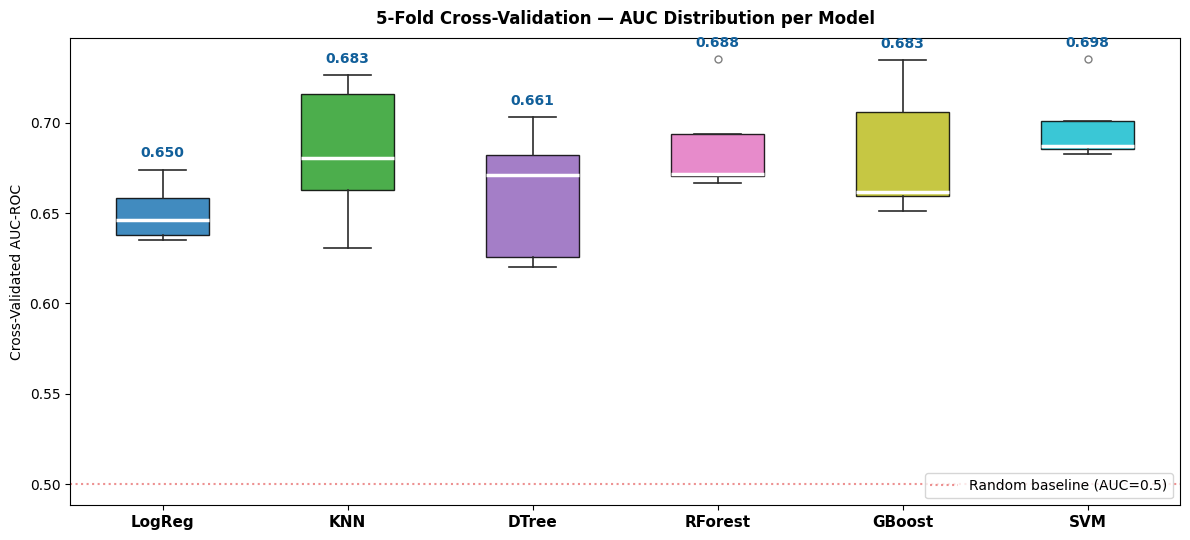

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — CV boxplot
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np


BLUE_D = "#115f9a" 
SLATE  = "#2b2b2b"

fig, ax = plt.subplots(figsize=(12, 5.5))


model_names  = list(trained.keys())
short_names  = ["LogReg", "KNN", "DTree", "RForest", "GBoost", "SVM"]


colors = plt.cm.tab10(np.linspace(0, 1, len(model_names)))

data_to_plot = [cv_scores[n] for n in model_names]


bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2.5))


for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for w in bp["whiskers"]: w.set(color=SLATE, linewidth=1.2)
for c in bp["caps"]:     c.set(color=SLATE, linewidth=1.2)
for f in bp["fliers"]:   f.set(marker="o", color=SLATE, alpha=0.5, markersize=5)

ax.set_xticks(range(1, len(model_names)+1))
ax.set_xticklabels(short_names, fontsize=11, fontweight="bold")
ax.set_ylabel("Cross-Validated AUC-ROC")
ax.set_title("5-Fold Cross-Validation — AUC Distribution per Model", pad=10, fontweight="bold")

ax.axhline(0.5, color="#dc2626", linewidth=1.5, linestyle=":", alpha=0.5,
           label="Random baseline (AUC=0.5)")
ax.legend(loc="lower right")


for i, name in enumerate(model_names):
    m = cv_scores[name].mean()
    box_max_val = cv_scores[name].max()
    ax.text(i+1, box_max_val + 0.005, f"{m:.3f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color=BLUE_D)

plt.tight_layout()
plt.show()



> 💡 **Reading the boxplot:** A **narrow box** with a high median = the model is both accurate *and* consistent across different data folds — exactly what you want to deploy in production. A tall box means results vary a lot depending on which data the model sees, making it less trustworthy.

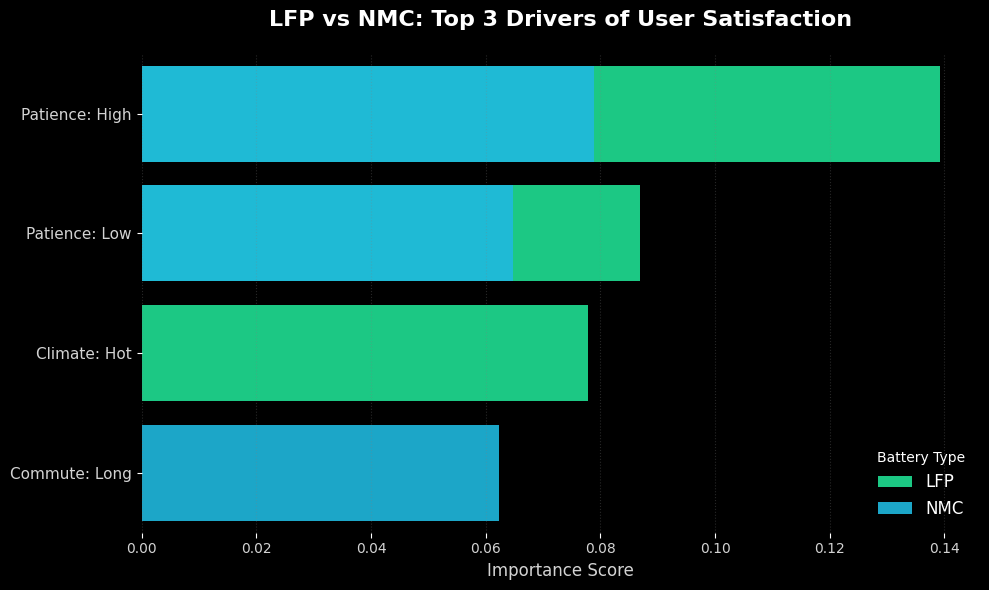


=== TOP 3 FACTORS FOR LFP SATISFACTION ===
          Feature  Importance Battery
LLM_Patience_High    0.139235     LFP
 LLM_Patience_Low    0.086835     LFP
  LLM_Climate_Hot    0.077773     LFP

=== TOP 3 FACTORS FOR NMC SATISFACTION ===
          Feature  Importance Battery
LLM_Patience_High    0.078832     NMC
 LLM_Patience_Low    0.064686     NMC
 LLM_Commute_Long    0.062395     NMC


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline




# Include all relevant features
features = ['LLM_Battery', 'LLM_Climate', 'LLM_Commute','LLM_Home_Charging', 'LLM_Patience', 'LLM_Brand']
target = 'LLM_Satisfaction'

# Split the dataset
df_lfp = df[df['LLM_Battery'] == 'LFP'].copy()
df_nmc = df[df['LLM_Battery'] == 'NMC'].copy()

def get_feature_importances(data):
    X = data[features]
    y = data[target]
    
    # One-Hot Encode
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), features)
        ])
    
    # Random Forest for Feature Importance
    rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
    
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', rf)])
    pipeline.fit(X, y)
    
    # Extract names and importances
    cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat']
    encoded_features = cat_encoder.get_feature_names_out(features)
    importances = pipeline.named_steps['classifier'].feature_importances_
    
    imp_df = pd.DataFrame({
        'Feature': encoded_features,
        'Importance': importances
    })
    
    # Completely remove 'Unknown' categories from the results
    imp_df = imp_df[~imp_df['Feature'].str.contains("_Unknown", case=False, na=False)]
    
    return imp_df.sort_values(by='Importance', ascending=False)

# Calculate importances
lfp_importances = get_feature_importances(df_lfp)
nmc_importances = get_feature_importances(df_nmc)

lfp_importances['Battery'] = 'LFP'
nmc_importances['Battery'] = 'NMC'

# Take ONLY the Top 3 factors for each
combined_imp = pd.concat([lfp_importances.head(3), nmc_importances.head(3)])

# Clean up feature names for a beautiful display
combined_imp['Feature'] = combined_imp['Feature'].str.replace('LLM_', '', regex=False)
combined_imp['Feature'] = combined_imp['Feature'].str.replace('_', ': ', regex=False)

# Beautiful Dark Mode Visualization
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

sns.barplot(
    data=combined_imp, 
    x='Importance', 
    y='Feature', 
    hue='Battery',
    palette={'LFP': '#00ff99', 'NMC': '#00ccff'}, # Neon Green & Neon Blue
    dodge=False,
    alpha=0.9
)

plt.title("LFP vs NMC: Top 3 Drivers of User Satisfaction", fontsize=16, fontweight='bold', pad=20, color='white')
plt.xlabel("Importance Score", fontsize=12, color='lightgray')
plt.ylabel("", fontsize=12)
plt.legend(title='Battery Type', fontsize=12, loc='lower right', frameon=False, labelcolor='white')

# Aesthetic adjustments
sns.despine(left=True, bottom=True)
plt.grid(axis='x', color='gray', linestyle=':', alpha=0.3)
plt.xticks(color='lightgray')
plt.yticks(color='lightgray', fontsize=11)

plt.tight_layout()
plt.savefig("lfp_vs_nmc_top3_dark.png", dpi=300, transparent=True)
plt.show()

# Print Results
print("\n=== TOP 3 FACTORS FOR LFP SATISFACTION ===")
print(lfp_importances.head(3).to_string(index=False))

print("\n=== TOP 3 FACTORS FOR NMC SATISFACTION ===")
print(nmc_importances.head(3).to_string(index=False))


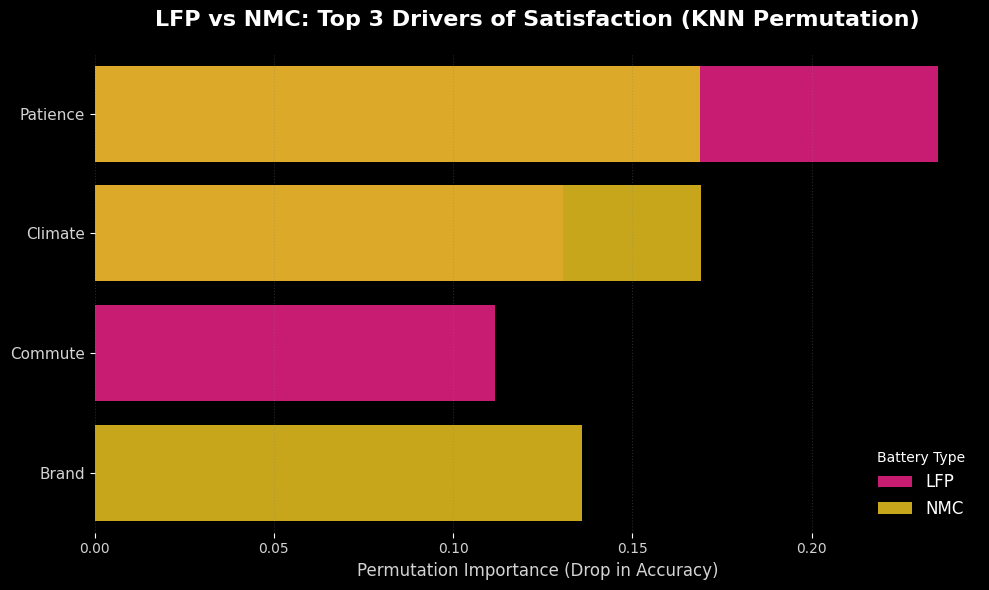


=== TOP 3 FACTORS FOR LFP (KNN) ===
     Feature  Importance Battery
LLM_Patience    0.235211     LFP
 LLM_Climate    0.130516     LFP
 LLM_Commute    0.111737     LFP

=== TOP 3 FACTORS FOR NMC (KNN) ===
     Feature  Importance Battery
 LLM_Climate    0.169254     NMC
LLM_Patience    0.168950     NMC
   LLM_Brand    0.136073     NMC


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance



# Include all relevant features
features = ['LLM_Battery', 'LLM_Climate', 'LLM_Commute','LLM_Home_Charging', 'LLM_Patience', 'LLM_Brand']
target = 'LLM_Satisfaction'

# Split the dataset
df_lfp = df[df['LLM_Battery'] == 'LFP'].copy()
df_nmc = df[df['LLM_Battery'] == 'NMC'].copy()

def get_knn_feature_importances(data):
    X = data[features]
    y = data[target]
    
    # One-Hot Encode
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), features)
        ])
    
    # Using your main model: KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', knn)])
    pipeline.fit(X, y)
    
    # Since KNN lacks built-in feature importance, we MUST use Permutation Importance.
    # It shuffles each feature and measures the drop in accuracy.
    result = permutation_importance(pipeline, X, y, n_repeats=10, random_state=42, n_jobs=-1)
    
    # Extract the mean importance for each base feature
    importances = result.importances_mean
    
    imp_df = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    })
    
    return imp_df.sort_values(by='Importance', ascending=False)

# Calculate importances using KNN Permutation
lfp_importances = get_knn_feature_importances(df_lfp)
nmc_importances = get_knn_feature_importances(df_nmc)

lfp_importances['Battery'] = 'LFP'
nmc_importances['Battery'] = 'NMC'

# Take ONLY the Top 3 factors for each
combined_imp = pd.concat([lfp_importances.head(3), nmc_importances.head(3)])

# Clean up feature names for a beautiful display
combined_imp['Feature'] = combined_imp['Feature'].str.replace('LLM_', '', regex=False)

# Beautiful Dark Mode Visualization
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

sns.barplot(
    data=combined_imp, 
    x='Importance', 
    y='Feature', 
    hue='Battery',
    palette={'LFP': '#ff007f', 'NMC': '#ffcc00'}, # Neon Pink & Neon Yellow
    dodge=False,
    alpha=0.9
)

plt.title("LFP vs NMC: Top 3 Drivers of Satisfaction (KNN Permutation)", fontsize=16, fontweight='bold', pad=20, color='white')
plt.xlabel("Permutation Importance (Drop in Accuracy)", fontsize=12, color='lightgray')
plt.ylabel("", fontsize=12)
plt.legend(title='Battery Type', fontsize=12, loc='lower right', frameon=False, labelcolor='white')

# Aesthetic adjustments
sns.despine(left=True, bottom=True)
plt.grid(axis='x', color='gray', linestyle=':', alpha=0.3)
plt.xticks(color='lightgray')
plt.yticks(color='lightgray', fontsize=11)

plt.tight_layout()
plt.savefig("lfp_vs_nmc_knn_top3_dark.png", dpi=300, transparent=True)
plt.show()

# Print Results
print("\n=== TOP 3 FACTORS FOR LFP (KNN) ===")
print(lfp_importances.head(3).to_string(index=False))

print("\n=== TOP 3 FACTORS FOR NMC (KNN) ===")
print(nmc_importances.head(3).to_string(index=False))


---

## 🎯 Section 10 — Final Model Selection

> **Choosing the right model** involves balancing performance, stability, speed, and interpretability. The dashboard below summarises all trade-offs in one view.

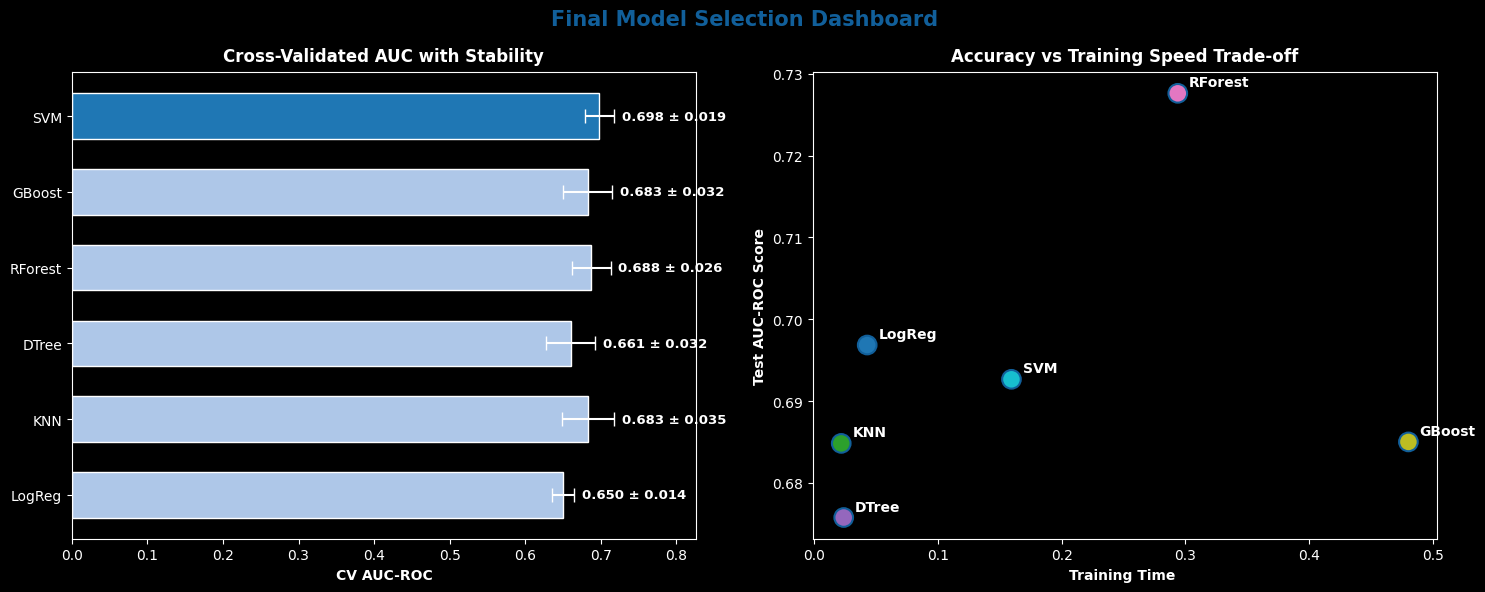

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Final comparison dashboard
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

BLUE_D = "#115f9a" 
BLUE   = "#1f77b4"
BLUE_L = "#aec7e8"
SLATE  = "#ffffff"

model_names  = list(trained.keys())
short_names  = ["LogReg", "KNN", "DTree", "RForest", "GBoost", "SVM"]
colors = plt.cm.tab10(np.linspace(0, 1, len(model_names)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Final Model Selection Dashboard", fontsize=15, fontweight="bold", color=BLUE_D)


ax = axes[0]
cv_means = [cv_scores[n].mean() for n in model_names]
cv_stds  = [cv_scores[n].std()  for n in model_names]
best_cv  = np.argmax(cv_means)


cv_cols  = [BLUE if i==best_cv else BLUE_L for i in range(len(model_names))]


ax.barh(short_names, cv_means, xerr=cv_stds, color=cv_cols, edgecolor="white",
        height=0.6, capsize=5, error_kw=dict(ecolor=SLATE, elinewidth=1.5))
ax.set_xlabel("CV AUC-ROC", fontweight="bold")
ax.set_title("Cross-Validated AUC with Stability", pad=8, fontweight="bold")


ax.set_xlim(0, max([m+s for m, s in zip(cv_means, cv_stds)]) * 1.15)

for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    ax.text(m+s+0.01, i, f"{m:.3f} ± {s:.3f}", va="center", fontsize=9.5, color=SLATE, fontweight="bold")


ax2 = axes[1]
test_aucs = results_df["AUC-ROC"].values
times     = [fit_times[n] for n in model_names]


ax2.scatter(times, test_aucs, s=180, c=colors, edgecolors=BLUE_D, linewidths=1.5, zorder=5)

for i, sn in enumerate(short_names):
    ax2.annotate(sn, (times[i], test_aucs[i]), xytext=(8,5), textcoords="offset points",
                 fontsize=10, color=SLATE, fontweight="bold")
    
ax2.set_xlabel("Training Time ", fontweight="bold")
ax2.set_ylabel("Test AUC-ROC Score", fontweight="bold")
ax2.set_title("Accuracy vs Training Speed Trade-off", pad=8, fontweight="bold")

plt.tight_layout()
plt.show()



---

## ⚙️ Section 11 — Hyperparameter Tuning

> **Lecture connection (Section 8 — Hyperparameter and Model Tuning):** Hyperparameters are set *before* training and control how the model learns. The lecture covers three categories and warns that *"tuning doesn't always improve your model."*

### Hyperparameter Categories (from Lecture)

| Category | What They Control | Examples |
|----------|------------------|---------|
| **Model** | Structure of the model | `max_depth`, `n_estimators`, `C` |
| **Optimizer** | How the model learns | `learning_rate`, solver type |
| **Data** | How training data is used | `subsample`, `min_samples_leaf` |

---

### 🔒 Which Data Is Used During Tuning?

```
All Data (100%)
│
├── 80% ── Training Set  ◄─── GridSearchCV / RandomizedSearchCV works HERE ONLY
│               │
│               ├── Fold 1: [✅ Validate] [Train] [Train] [Train] [Train]
│               ├── Fold 2: [Train] [✅ Validate] [Train] [Train] [Train]
│               ├── Fold 3: [Train] [Train] [✅ Validate] [Train] [Train]
│               ├── Fold 4: [Train] [Train] [Train] [✅ Validate] [Train]
│               └── Fold 5: [Train] [Train] [Train] [Train] [✅ Validate]
│                               │
│                               └── Best hyperparameters = highest average CV AUC
│
└── 20% ── Test Set  ◄─── NEVER touched during tuning. Used ONCE at the very end.
```

> 🚨 **Why this matters:** If you use the test set to guide hyperparameter choices, you are indirectly fitting to it — the final evaluation is no longer honest. The **test set is the final exam**; cross-validation is the practice run. Both `GridSearchCV` and `RandomizedSearchCV` below receive **only `X_train_sc` and `y_train`**.

---

### Tuning Strategies

| Strategy | How It Works | Trade-off |
|----------|-------------|-----------|
| **Grid Search** | Exhaustively tries every combination | Thorough but slow |
| **Random Search** | Randomly samples combinations | Faster — good near-optimal results with fewer trials |
| **Bayesian** | Uses past results to pick next candidates | Most efficient — used in AWS SageMaker Autopilot |

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Baseline AUC scores before tuning 
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score

baseline = {
    "Gradient Boosting" : roc_auc_score(y_test, trained["Gradient Boosting"].predict_proba(X_test), multi_class="ovr", average="weighted"),
    "Random Forest"     : roc_auc_score(y_test, trained["Random Forest"].predict_proba(X_test), multi_class="ovr", average="weighted"),
}

print("Baseline Test AUC-ROC (before tuning):")
for name, score in baseline.items():
    print(f"  {name:<25} AUC = {score:.4f}")



Baseline Test AUC-ROC (before tuning):
  Gradient Boosting         AUC = 0.6850
  Random Forest             AUC = 0.7276


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Grid Search on Gradient Boosting (PIPELINE COMPATIBLE)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


from sklearn.utils.class_weight import compute_sample_weight

gb_param_grid = {
    "clf__n_estimators" : [100, 200],       
    "clf__max_depth"    : [3, 5],           
    "clf__learning_rate": [0.05, 0.10],     
    "clf__subsample"    : [0.8, 1.0],       
}

print(f"Grid Search: {2*2*2*2} combinations × 5 folds = {2*2*2*2*5} fits")
print("Running ...\n")

gb_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("enc", OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ("clf", GradientBoostingClassifier(random_state=SEED))
])

gs_gb = GridSearchCV(
    gb_pipe,  
    param_grid=gb_param_grid, 
    cv=5, 
    scoring="roc_auc_ovr_weighted", 
    n_jobs=-1, 
    verbose=0,
)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)


gs_gb.fit(X_train, y_train, clf__sample_weight=sample_weights)

tuned_gb_auc = roc_auc_score(
    y_test, 
    gs_gb.best_estimator_.predict_proba(X_test), 
    multi_class="ovr", 
    average="weighted"
)

print("Best parameters found:")
for k, v in gs_gb.best_params_.items():
    print(f"  {k:<20} = {v}")
print(f"\nBest CV AUC  : {gs_gb.best_score_:.4f}")
print(f"Test AUC     : {tuned_gb_auc:.4f}")


print(f"Baseline AUC : {baseline['Gradient Boosting']:.4f}")
print(f"Improvement  : {tuned_gb_auc - baseline['Gradient Boosting']:+.4f}")



Grid Search: 16 combinations × 5 folds = 80 fits
Running ...

Best parameters found:
  clf__learning_rate   = 0.1
  clf__max_depth       = 3
  clf__n_estimators    = 100
  clf__subsample       = 1.0

Best CV AUC  : 0.6913
Test AUC     : 0.7012
Baseline AUC : 0.6850
Improvement  : +0.0161


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Randomized Search on Random Forest (PIPELINE COMPATIBLE)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


rf_param_dist = {
    "clf__n_estimators"     : randint(100, 400),
    "clf__max_depth"        : randint(5, 20),
    "clf__min_samples_split": randint(2, 20),
    "clf__min_samples_leaf" : randint(1, 10),
    "clf__max_features"     : ["sqrt", "log2", 0.5],
}

print("Randomized Search: 15 combinations × 5 folds = 75 fits")
print("Running...\n")


rf_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("enc", OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ("clf", RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1))
])

rs_rf = RandomizedSearchCV(
    rf_pipe, 
    param_distributions=rf_param_dist,
    n_iter=15, 
    cv=5, 
    scoring="roc_auc_ovr_weighted",
    random_state=SEED, 
    n_jobs=-1, 
    verbose=0,
)


rs_rf.fit(X_train, y_train)


tuned_rf_auc = roc_auc_score(
    y_test, 
    rs_rf.best_estimator_.predict_proba(X_test),
    multi_class="ovr", 
    average="weighted"
)

print("Best parameters found:")
for k, v in rs_rf.best_params_.items():
    print(f"  {k:<25} = {v}")
print(f"\nBest CV AUC  : {rs_rf.best_score_:.4f}")
print(f"Test AUC     : {tuned_rf_auc:.4f}")
print(f"Baseline AUC : {baseline['Random Forest']:.4f}")
print(f"Improvement  : {tuned_rf_auc - baseline['Random Forest']:+.4f}")


Randomized Search: 15 combinations × 5 folds = 75 fits
Running...

Best parameters found:
  clf__max_depth            = 19
  clf__max_features         = log2
  clf__min_samples_leaf     = 3
  clf__min_samples_split    = 13
  clf__n_estimators         = 154

Best CV AUC  : 0.7083
Test AUC     : 0.7183
Baseline AUC : 0.7276
Improvement  : -0.0093


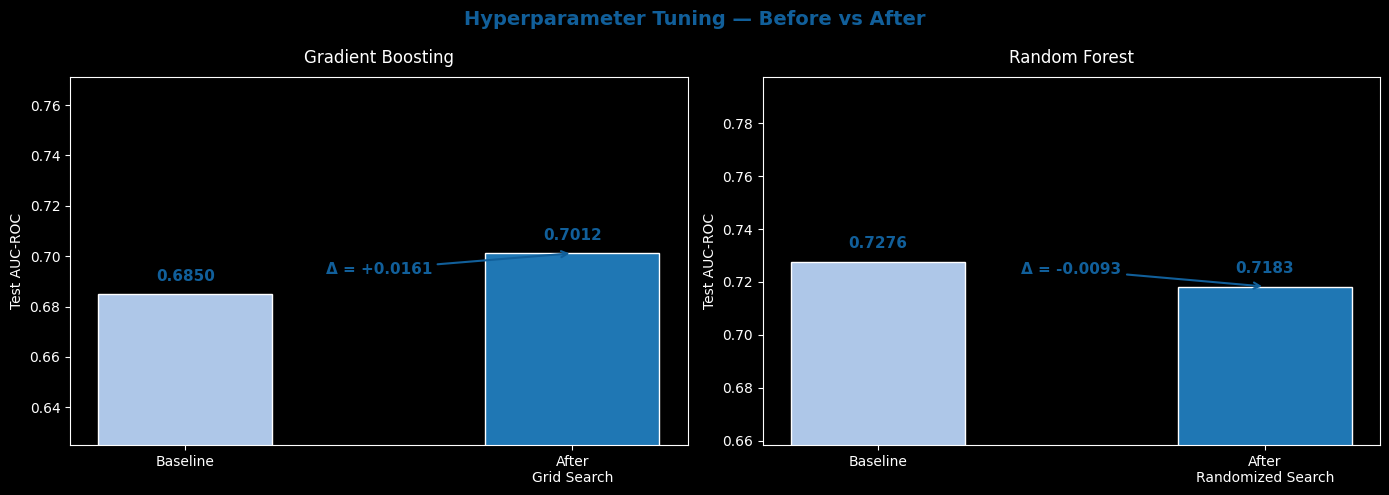

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 20 — Before vs After tuning comparison
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hyperparameter Tuning — Before vs After", fontsize=14,
             fontweight="bold", color=BLUE_D)

for ax, (mname, before, after, strategy) in zip(axes, [
    ("Gradient Boosting", baseline["Gradient Boosting"], tuned_gb_auc, "Grid Search"),
    ("Random Forest",     baseline["Random Forest"],     tuned_rf_auc, "Randomized Search"),
]):
    vals   = [before, after]
    labels = ["Baseline", f"After\n{strategy}"]
    colors = [BLUE_L, BLUE]
    bars   = ax.bar(labels, vals, color=colors, edgecolor="white", width=0.45)
    ax.set_ylim(max(0, min(vals)-0.06), min(1.0, max(vals)+0.07))
    ax.set_ylabel("Test AUC-ROC")
    ax.set_title(mname, pad=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold", color=BLUE_D)
    delta = after - before
    ax.annotate(f"\u0394 = {delta:+.4f}",
                xy=(1, after), xytext=(0.5, (before+after)/2),
                fontsize=11, color=BLUE_D, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=BLUE_D, lw=1.5), ha="center")

plt.tight_layout()
plt.show()



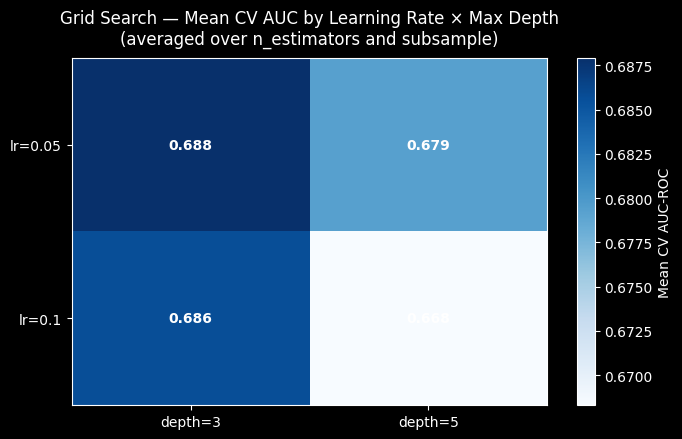

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 21 — Grid search heatmap: learning_rate × max_depth (PIPELINE FIX)
# ─────────────────────────────────────────────────────────────────────────────
cv_results = pd.DataFrame(gs_gb.cv_results_)

pivot = cv_results.groupby(
    ["param_clf__learning_rate","param_clf__max_depth"]
)["mean_test_score"].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(pivot.values, cmap="Blues", aspect="auto",
               vmin=pivot.values.min(), vmax=pivot.values.max())

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))

ax.set_xticklabels([f"depth={v}" for v in pivot.columns], fontsize=10)
ax.set_yticklabels([f"lr={v}" for v in pivot.index], fontsize=10)

ax.set_title("Grid Search — Mean CV AUC by Learning Rate × Max Depth\n"
             "(averaged over n_estimators and subsample)", pad=10)

plt.colorbar(im, ax=ax, label="Mean CV AUC-ROC")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i,j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=10,
                fontweight="bold",
                color="white" if val > pivot.values.mean() else SLATE)

plt.tight_layout()
plt.show()




In [25]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

rf_param_dist = {
    "clf__n_estimators"     : randint(100, 500),
    "clf__max_depth"        : randint(5, 25),
    "clf__min_samples_split": randint(2, 15),
    "clf__min_samples_leaf" : randint(1, 10),
    "clf__max_features"     : ["sqrt", "log2", 0.5],
}

rf_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("enc", OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ("clf", RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1))
])
rs_rf = RandomizedSearchCV(
    rf_pipe, 
    param_distributions=rf_param_dist,
    n_iter=20, 
    cv=5, 
    scoring="roc_auc_ovr_weighted",
    random_state=SEED, 
    n_jobs=-1, 
    verbose=1
)
print("Random Forest Hyperparameter Tuning ...\n")
rs_rf.fit(X_train, y_train)
best_pipe = rs_rf.best_estimator_
print("\nBest Parameters:")
for k, v in rs_rf.best_params_.items():
    print(f"  {k:<25} = {v}")
print(f"\nBest CV AUC  : {rs_rf.best_score_:.4f}")

Random Forest Hyperparameter Tuning ...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
  clf__max_depth            = 21
  clf__max_features         = 0.5
  clf__min_samples_leaf     = 3
  clf__min_samples_split    = 13
  clf__n_estimators         = 154

Best CV AUC  : 0.7075


In [26]:
from sklearn.metrics import classification_report
import pandas as pd
y_pred_rf = best_pipe.predict(X_test)
report_dict = classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, output_dict=True)
per_class_df = pd.DataFrame(report_dict).transpose().loc[CLASS_NAMES]
print(f"\nRandom Forest Performance Report\n")
styled_table = (per_class_df
    .style
    .format("{:.4f}")
    .background_gradient(cmap="Blues", subset=["f1-score"])
    .apply(lambda x: ['background-color: #ffe4e6' if x.name == 'Neutral' else '' for _ in x], axis=1) 
)
display(styled_table)


Random Forest Performance Report



,precision,recall,f1-score,support
Negative,0.4231,0.6875,0.5238,32.0000
Neutral,0.3966,0.4259,0.4107,54.0000
Positive,0.7500,0.5455,0.6316,88.0000


In [27]:
import joblib

save_path = r"C:\Users\Keramettin\Desktop\projectPDS\sunum\ev_sentiment_model.joblib"
joblib.dump(best_pipe, save_path)


secilen_model = type(best_pipe.steps[-1][1]).__name__

print("="*40)
print(f"✅ Saved!")
print(f"📌 Chosen Model: {secilen_model}")
print(f"📁 Saved Path: {save_path}")
print("="*40)




✅ Saved!
📌 Chosen Model: RandomForestClassifier
📁 Saved Path: C:\Users\Keramettin\Desktop\projectPDS\sunum\ev_sentiment_model.joblib


---

## ✅ Section 12 — Key Takeaways

> **Lecture alignment summary:** This notebook directly implements Sections 5, 6, and 8 of the AWS ML Foundations Module 3 lecture.

### Lecture Concept Coverage

| Lecture Topic | Section | Covered In Notebook |
|--------------|---------|---------------------|
| Why split data / overfitting risk | §5 | Section 2 |
| Holdout method (train / test) | §5 | Section 2 |
| Stratified splitting (preserve class ratio) | §5 | Section 2 |
| K-fold cross-validation | §5 & §6 | Section 9 |
| Shuffle data before splitting | §5 | Section 2 (`random_state`) |
| Confusion matrix (TP, FP, FN, TN) | §6 | Section 4 & Section 6 |
| Sensitivity & Specificity | §6 | Section 4 & Section 8 |
| Accuracy, Precision, F1 score | §6 | Section 4 & throughout |
| ROC curve & AUC-ROC | §6 | Section 7 |
| Threshold selection based on business case | §6 | Section 7 callout |
| Hyperparameter categories (Model/Optimizer/Data) | §8 | Section 11 |
| Grid Search & Randomized Search | §8 | Section 11 |
| Tuning uses training data only | §8 | Section 11 diagram |

### What We Built — End-to-End
1. **Loaded & split** data with stratification to preserve class balance
2. **Trained 6 classifiers** — from Logistic Regression to Gradient Boosting
3. **Evaluated** with confusion matrices, precision, recall, F1, and AUC-ROC
4. **Visualised** ROC curves for all models on one chart
5. **Diagnosed** the best model with per-class metrics and feature importance
6. **Validated** with 5-fold cross-validation (AUC scoring)
7. **Tuned** hyperparameters with Grid Search and Randomized Search — training data only
###
**Yasin Eren Alacahan 222010020007**
**Emre Erkut 222010020156**
**Keramettin Kutnu 222010020155**

---
> *Built with scikit-learn · pandas · matplotlib · seaborn — Classification Training & Evaluation*